In [58]:
import torch
print(torch.cuda.is_available())

True


In [59]:
import os
import re
import time
import random
import numpy as np
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from torch.nn.utils.rnn import pack_padded_sequence
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
import nltk


In [60]:

# Installation automatique des bibliothèques manquantes sur Kaggle
import subprocess
import sys
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    from rouge_score import rouge_scorer
except ImportError:
    print("Installing rouge-score...")
    install('rouge-score')
    from rouge_score import rouge_scorer

try:
    from pycocoevalcap.cider.cider import Cider
except ImportError:
    print("Installing pycocoevalcap...")
    install('pycocoevalcap')
    from pycocoevalcap.cider.cider import Cider

try:
    nltk.download('wordnet')
    nltk.download('omw-1.4')
except:
    pass

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# 1. SETUP ET HYPERPARAMÈTRES


In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Chemins Kaggle
DATA_DIR = "/kaggle/input/datasets/adityajn105/flickr8k"
IMG_DIR = os.path.join(DATA_DIR, "Images")
CAPTION_FILE = os.path.join(DATA_DIR, "captions.txt")

# Hyperparamètres
EMBED_DIM = 256
ATTENTION_DIM = 256
DECODER_DIM = 512
DROPOUT = 0.5
BATCH_SIZE = 32
EPOCHS = 20
LR = 4e-4
MIN_FREQ = 5

Using device: cuda


# 2. PRÉPARATION DES DONNÉES ET VOCABULAIRE


In [62]:
def load_captions(filepath):
    captions_dict = {}
    if not os.path.exists(filepath):
        print(f"Warning: Dataset not found at {filepath}. Please run this on Kaggle.")
        return {}
    with open(filepath, 'r') as f:
        next(f)  # skip header
        for line in f:
            parts = line.strip().split(',', 1)
            if len(parts) != 2: continue
            img_name = parts[0].split('#')[0]
            caption = parts[1].lower()
            caption = re.sub(r'[^a-z0-9 ]+', '', caption)
            if img_name not in captions_dict:
                captions_dict[img_name] = []
            captions_dict[img_name].append(caption)
    return captions_dict

captions_dict = load_captions(CAPTION_FILE)
all_images = list(captions_dict.keys())

class Vocabulary:
    def __init__(self, min_freq):
        self.min_freq = min_freq
        self.word2idx = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}
        self.idx2word = {0: "<pad>", 1: "<start>", 2: "<end>", 3: "<unk>"}
        self.idx = 4

    def build_vocab(self, captions_list):
        counter = Counter()
        for caps in captions_list:
            for cap in caps:
                counter.update(cap.split())
        for word, freq in counter.items():
            if freq >= self.min_freq:
                self.word2idx[word] = self.idx
                self.idx2word[self.idx] = word
                self.idx += 1

    def numericalize(self, text):
        return [self.word2idx.get(w, self.word2idx["<unk>"]) for w in text.split()]

vocab = Vocabulary(MIN_FREQ)
if captions_dict:
    vocab.build_vocab(captions_dict.values())

class Flickr8kDataset(Dataset):
    def __init__(self, img_names, captions_dict, img_dir, vocab, transform=None):
        self.img_dir = img_dir
        self.vocab = vocab
        self.transform = transform
        self.dataset = [(img, cap) for img in img_names for cap in captions_dict[img]]
                
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        img_name, caption = self.dataset[index]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        tokens = [self.vocab.word2idx["<start>"]] + self.vocab.numericalize(caption) + [self.vocab.word2idx["<end>"]]
        return image, torch.tensor(tokens), img_name

class CollateFn:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx
        
    def __call__(self, batch):
        imgs = torch.cat([item[0].unsqueeze(0) for item in batch], dim=0)
        targets = torch.nn.utils.rnn.pad_sequence([item[1] for item in batch], batch_first=True, padding_value=self.pad_idx)
        img_names = [item[2] for item in batch]
        return imgs, targets, img_names

# DataLoaders
if all_images:
    random.seed(42)
    random.shuffle(all_images)
    split_train, split_val = int(0.8 * len(all_images)), int(0.9 * len(all_images))
    train_imgs, val_imgs, test_imgs = all_images[:split_train], all_images[split_train:split_val], all_images[split_val:]

    transform_train = transforms.Compose([
        transforms.Resize((256, 256)), transforms.RandomCrop(224), transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    transform_val = transforms.Compose([
        transforms.Resize((224, 224)), transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    pad_idx = vocab.word2idx["<pad>"]
    collate_fn = CollateFn(pad_idx)

    train_loader = DataLoader(Flickr8kDataset(train_imgs, captions_dict, IMG_DIR, vocab, transform_train), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2, pin_memory=True)
    val_loader = DataLoader(Flickr8kDataset(val_imgs, captions_dict, IMG_DIR, vocab, transform_val), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)
    test_loader = DataLoader(Flickr8kDataset(test_imgs, captions_dict, IMG_DIR, vocab, transform_val), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)
else:
    train_loader = val_loader = test_loader = []
    pad_idx = 0



# 3. MODÈLES

In [63]:

# --- A. ENCODEURS VISUELS ---
class EncoderCNN(nn.Module):
    """Pour Baseline (CNN + LSTM) : Extrait un seul vecteur global."""
    def __init__(self, embed_dim):
        super(EncoderCNN, self).__init__()
        resnet = models.resnet50(pretrained=True)
        self.resnet = nn.Sequential(*list(resnet.children())[:-1])
        self.linear = nn.Linear(resnet.fc.in_features, embed_dim)
        self.bn = nn.BatchNorm1d(embed_dim, momentum=0.01)
        for param in self.resnet.parameters():
            param.requires_grad = False
            
    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)
        features = features.view(features.size(0), -1)
        return self.bn(self.linear(features))

class SpatialEncoderCNN(nn.Module):
    """Pour l'Attention & Transformer : Extrait une carte de caractéristiques spatiales (ex: 14x14)."""
    def __init__(self):
        super(SpatialEncoderCNN, self).__init__()
        resnet = models.resnet50(pretrained=True)
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])
        for param in self.resnet.parameters():
            param.requires_grad = False
            
    def forward(self, images):
        out = self.resnet(images) # (batch, 2048, 7, 7)
        out = out.permute(0, 2, 3, 1) # (batch, 7, 7, 2048)
        return out.view(out.size(0), -1, out.size(-1)) # (batch, 49, 2048)


In [64]:
# --- B. DÉCODEUR BASELINE (LSTM sans attention) ---
class DecoderLSTM(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size, num_layers=1):
        super(DecoderLSTM, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, features, captions):
        embeddings = self.embed(captions[:, :-1])
        embeddings = torch.cat((features.unsqueeze(1), embeddings), dim=1)
        hiddens, _ = self.lstm(embeddings)
        return self.linear(hiddens[:, 1:, :])


In [65]:
# --- C. DÉCODEUR SOFT ATTENTION (Show, Attend and Tell) ---
class SoftAttention(nn.Module):
    """Calcule l'attention douce (Soft Attention). Differentiable."""
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(SoftAttention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2)
        alpha = self.softmax(att)
        attention_weighted_encoding = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return attention_weighted_encoding, alpha

class DecoderWithAttention(nn.Module):
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim=2048, dropout=0.5):
        super(DecoderWithAttention, self).__init__()
        self.vocab_size = vocab_size
        self.attention = SoftAttention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(p=dropout)
        self.decode_step = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(decoder_dim, vocab_size)
        
    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        return self.init_h(mean_encoder_out), self.init_c(mean_encoder_out)
        
    def forward(self, encoder_out, encoded_captions, caption_lengths):
        batch_size = encoder_out.size(0)
        caption_lengths, sort_ind = caption_lengths.sort(dim=0, descending=True)
        encoder_out = encoder_out[sort_ind]
        encoded_captions = encoded_captions[sort_ind]
        
        embeddings = self.embedding(encoded_captions)
        h, c = self.init_hidden_state(encoder_out)
        
        decode_lengths = (caption_lengths - 1).tolist()
        max_length = max(decode_lengths)
        
        predictions = torch.zeros(batch_size, max_length, self.vocab_size).to(device)
        alphas = torch.zeros(batch_size, max_length, encoder_out.size(1)).to(device)
        
        for t in range(max_length):
            batch_size_t = sum([l > t for l in decode_lengths])
            attention_weighted_encoding, alpha = self.attention(encoder_out[:batch_size_t], h[:batch_size_t])
            gate = self.sigmoid(self.f_beta(h[:batch_size_t]))
            attention_weighted_encoding = gate * attention_weighted_encoding
            
            h, c = self.decode_step(
                torch.cat([embeddings[:batch_size_t, t, :], attention_weighted_encoding], dim=1),
                (h[:batch_size_t], c[:batch_size_t])
            )
            predictions[:batch_size_t, t, :] = self.fc(self.dropout(h))
            alphas[:batch_size_t, t, :] = alpha
            
        return predictions, encoded_captions, decode_lengths, alphas, sort_ind


In [66]:

# --- D. DÉCODEUR HARD ATTENTION ---
class HardAttention(nn.Module):
    """
    Pseudo-Hard Attention: Utilise argmax sur les poids d'attention pour sélectionner 
    EXACTEMENT un seul vecteur spatial.
    
    IMPORTANT: Argmax est non-différentiable. Dans une vraie architecture Hard Attention (comme l'article SAT),
    on utiliserait l'apprentissage par renforcement (Reinforcement Learning - REINFORCE) pour
    estimer les gradients. Ici, on propose une version simplifiée pour démontrer le mécanisme.
    """
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(HardAttention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2)
        alpha = self.softmax(att) # (batch, 49)
        
        # Hard attention: on prend SEULEMENT la région avec le max d'attention.
        max_idx = torch.argmax(alpha, dim=1) # (batch)
        
        batch_size = encoder_out.size(0)
        attention_weighted_encoding = encoder_out[torch.arange(batch_size), max_idx, :] # (batch, encoder_dim)
        
        return attention_weighted_encoding, alpha

class DecoderHardAttention(DecoderWithAttention):
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim=2048, dropout=0.5):
        super(DecoderHardAttention, self).__init__(attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim, dropout)
        # Remplace l'attention douce par l'attention dure
        self.attention = HardAttention(encoder_dim, decoder_dim, attention_dim)


In [67]:
# --- E. DÉCODEUR TRANSFORMER ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class DecoderTransformer(nn.Module):
    """Remplace le LSTM par nn.TransformerDecoder (Multi-Head Attention)."""
    def __init__(self, embed_dim, vocab_size, encoder_dim=2048, num_heads=8, num_layers=3, dropout=0.1):
        super(DecoderTransformer, self).__init__()
        self.vocab_size = vocab_size
        self.encoder_proj = nn.Linear(encoder_dim, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoder = PositionalEncoding(embed_dim, dropout)
        
        decoder_layer = nn.TransformerDecoderLayer(d_model=embed_dim, nhead=num_heads, 
                                                   dim_feedforward=embed_dim*4, dropout=dropout, batch_first=True)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(embed_dim, vocab_size)
        
    def generate_square_subsequent_mask(self, sz):
        # Boolean mask: True means "do not attend"
        return torch.triu(torch.ones(sz, sz, device=device, dtype=torch.bool), diagonal=1)
        
    def forward(self, encoder_out, captions):
        memory = self.encoder_proj(encoder_out)
        
        captions_input = captions[:, :-1]
        tgt = self.embedding(captions_input)
        tgt = self.pos_encoder(tgt)
        
        tgt_mask = self.generate_square_subsequent_mask(tgt.size(1)).to(device)
        tgt_key_padding_mask = (captions_input == pad_idx).to(device)
        
        output = self.transformer_decoder(tgt, memory, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_key_padding_mask)
        return self.fc_out(output)



# 4. FONCTIONS D'ENTRAÎNEMENT & ÉVALUATION


In [68]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx).to(device)

def train_base_or_transformer(encoder, decoder, loader, optimizer):
    encoder.train()
    decoder.train()
    epoch_loss = 0
    for imgs, caps, _ in loader:
        imgs, caps = imgs.to(device), caps.to(device)
        features = encoder(imgs)
        outputs = decoder(features, caps)
        targets = caps[:, 1:].reshape(-1)
        outputs = outputs.reshape(-1, outputs.shape[-1])
        loss = criterion(outputs, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def train_attention(encoder, decoder, loader, optimizer, alpha_c=1.0):
    encoder.train()
    decoder.train()
    epoch_loss = 0
    for imgs, caps, _ in loader:
        imgs, caps = imgs.to(device), caps.to(device)
        lengths = torch.tensor([torch.sum(cap != pad_idx).item() for cap in caps]).to(device)
        encoder_out = encoder(imgs)
        predictions, caps_sorted, decode_lengths, alphas, _ = decoder(encoder_out, caps, lengths)
        
        targets = caps_sorted[:, 1:]
        predictions = pack_padded_sequence(predictions, decode_lengths, batch_first=True).data
        targets = pack_padded_sequence(targets, decode_lengths, batch_first=True).data
        
        loss = criterion(predictions, targets)
        loss += alpha_c * ((1. - alphas.sum(dim=1)) ** 2).mean() # Doubly stochastic regularization
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def evaluate_model(model_type, encoder, decoder, loader):
    encoder.eval()
    decoder.eval()
    references, hypotheses = [], []
    img_ids_list = []
    epoch_loss = 0
    
    with torch.no_grad():
        for imgs, caps, img_names in loader:
            imgs, caps = imgs.to(device), caps.to(device)
            
            if model_type in ['baseline', 'transformer']:
                features = encoder(imgs)
                outputs = decoder(features, caps)
                targets = caps[:, 1:].reshape(-1)
                loss = criterion(outputs.reshape(-1, outputs.shape[-1]), targets)
                epoch_loss += loss.item()
                preds = outputs.argmax(2)
                sort_ind = list(range(len(imgs)))
                
            else: # soft or hard attention
                lengths = torch.tensor([torch.sum(cap != pad_idx).item() for cap in caps]).to(device)
                encoder_out = encoder(imgs)
                predictions, caps_sorted, decode_lengths, alphas, sort_ind = decoder(encoder_out, caps, lengths)
                
                targets = caps_sorted[:, 1:]
                preds_packed = pack_padded_sequence(predictions, decode_lengths, batch_first=True).data
                targets_packed = pack_padded_sequence(targets, decode_lengths, batch_first=True).data
                loss = criterion(preds_packed, targets_packed)
                epoch_loss += loss.item()
                preds = predictions.argmax(2)

            img_names_sorted = [img_names[idx] for idx in sort_ind]
            for i in range(preds.shape[0]):
                pred_words = [vocab.idx2word[w.item()] for w in preds[i] if w.item() not in [0, 1, pad_idx]]
                if "<end>" in pred_words: pred_words = pred_words[:pred_words.index("<end>")]
                hypotheses.append(pred_words)
                references.append([cap.split() for cap in captions_dict[img_names_sorted[i]]])
                img_ids_list.append(img_names_sorted[i])

    # Calcul des métriques
    metrics = {}
    if references:
        # BLEU 1-4
        metrics['bleu1'] = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0))
        metrics['bleu2'] = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0))
        metrics['bleu3'] = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0))
        metrics['bleu4'] = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))
        
        # METEOR
        try:
            m_scores = [meteor_score(ref, hyp) for ref, hyp in zip(references, hypotheses)]
            metrics['meteor'] = sum(m_scores) / len(m_scores)
        except:
            metrics['meteor'] = 0.0
            
        # ROUGE-L (via rouge-score library)
        try:
            scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
            r_scores = []
            for refs_i, hyp_i in zip(references, hypotheses):
                hyp_str = " ".join(hyp_i)
                # On compare l'hypothèse à toutes les références et on prend le max
                best_r = max([scorer.score(" ".join(r), hyp_str)['rougeL'].fmeasure for r in refs_i])
                r_scores.append(best_r)
            metrics['rouge_l'] = sum(r_scores) / len(r_scores)
        except:
            metrics['rouge_l'] = 0.0
        
        # CIDEr (via pycocoevalcap)
        try:
            cider_scorer = Cider()
            gts = {i: [" ".join(r) for r in refs_i] for i, refs_i in enumerate(references)}
            res = {i: [" ".join(hyp_i)] for i, hyp_i in enumerate(hypotheses)}
            score, _ = cider_scorer.compute_score(gts, res)
            metrics['cider'] = score
        except Exception as e:
            print(f"CIDEr error: {e}")
            metrics['cider'] = 0.0
        
    avg_loss = epoch_loss / len(loader) if len(loader) > 0 else 0
    return avg_loss, metrics


# 5.ENTRAÎNEMENT


In [69]:
history = {
    'Baseline': {'train': [], 'val': [], 'metrics': []},
    'Soft Attention': {'train': [], 'val': [], 'metrics': []},
    'Hard Attention': {'train': [], 'val': [], 'metrics': []},
    'Transformer': {'train': [], 'val': [], 'metrics': []}
}

if len(train_loader) > 0:
    print("Initialisation des modèles...")
    # 1. Baseline
    base_enc = EncoderCNN(EMBED_DIM).to(device)
    base_dec = DecoderLSTM(EMBED_DIM, DECODER_DIM, len(vocab.word2idx)).to(device)
    base_opt = optim.Adam(list(base_enc.linear.parameters()) + list(base_enc.bn.parameters()) + list(base_dec.parameters()), lr=LR)
    
    # 2 & 3. Attention Models
    spatial_enc = SpatialEncoderCNN().to(device)
    soft_dec = DecoderWithAttention(ATTENTION_DIM, EMBED_DIM, DECODER_DIM, len(vocab.word2idx)).to(device)
    soft_opt = optim.Adam(soft_dec.parameters(), lr=LR)
    
    hard_dec = DecoderHardAttention(ATTENTION_DIM, EMBED_DIM, DECODER_DIM, len(vocab.word2idx)).to(device)
    hard_opt = optim.Adam(hard_dec.parameters(), lr=LR)
    
    # 4. Transformer
    trans_dec = DecoderTransformer(EMBED_DIM, len(vocab.word2idx)).to(device)
    trans_opt = optim.Adam(trans_dec.parameters(), lr=LR)

    print("Début de l'entraînement...")
    for epoch in range(1, EPOCHS+1):
        print(f"\n--- EPOCH {epoch}/{EPOCHS} ---")
        
        # Baseline
        tr = train_base_or_transformer(base_enc, base_dec, train_loader, base_opt)
        vl, m = evaluate_model('baseline', base_enc, base_dec, val_loader)
        history['Baseline']['train'].append(tr); history['Baseline']['val'].append(vl); history['Baseline']['metrics'].append(m)
        print(f"Baseline       - Loss: {vl:.4f}, B1-4: [{m['bleu1']:.2f}, {m['bleu2']:.2f}, {m['bleu3']:.2f}, {m['bleu4']:.2f}], MET: {m['meteor']:.2f}")
        
        # Soft Attention
        tr = train_attention(spatial_enc, soft_dec, train_loader, soft_opt)
        vl, m = evaluate_model('soft', spatial_enc, soft_dec, val_loader)
        history['Soft Attention']['train'].append(tr); history['Soft Attention']['val'].append(vl); history['Soft Attention']['metrics'].append(m)
        print(f"Soft Attention - Loss: {vl:.4f}, B1-4: [{m['bleu1']:.2f}, {m['bleu2']:.2f}, {m['bleu3']:.2f}, {m['bleu4']:.2f}], MET: {m['meteor']:.2f}")
        
        # Hard Attention
        tr = train_attention(spatial_enc, hard_dec, train_loader, hard_opt)
        vl, m = evaluate_model('hard', spatial_enc, hard_dec, val_loader)
        history['Hard Attention']['train'].append(tr); history['Hard Attention']['val'].append(vl); history['Hard Attention']['metrics'].append(m)
        print(f"Hard Attention - Loss: {vl:.4f}, B1-4: [{m['bleu1']:.2f}, {m['bleu2']:.2f}, {m['bleu3']:.2f}, {m['bleu4']:.2f}], MET: {m['meteor']:.2f}")
        
        # Transformer
        tr = train_base_or_transformer(spatial_enc, trans_dec, train_loader, trans_opt)
        vl, m = evaluate_model('transformer', spatial_enc, trans_dec, val_loader)
        history['Transformer']['train'].append(tr); history['Transformer']['val'].append(vl); history['Transformer']['metrics'].append(m)
        print(f"Transformer    - Loss: {vl:.4f}, B1-4: [{m['bleu1']:.2f}, {m['bleu2']:.2f}, {m['bleu3']:.2f}, {m['bleu4']:.2f}], MET: {m['meteor']:.2f}")



Initialisation des modèles...
Début de l'entraînement...

--- EPOCH 1/20 ---
Baseline       - Loss: 3.3254, B1-4: [0.58, 0.35, 0.19, 0.10], MET: 0.29
Soft Attention - Loss: 3.3763, B1-4: [0.61, 0.38, 0.21, 0.12], MET: 0.31
Hard Attention - Loss: 3.4444, B1-4: [0.59, 0.35, 0.18, 0.10], MET: 0.29
Transformer    - Loss: 3.1041, B1-4: [0.61, 0.39, 0.23, 0.14], MET: 0.32

--- EPOCH 2/20 ---
Baseline       - Loss: 3.0223, B1-4: [0.61, 0.38, 0.22, 0.12], MET: 0.32
Soft Attention - Loss: 3.0931, B1-4: [0.62, 0.40, 0.23, 0.13], MET: 0.32
Hard Attention - Loss: 3.1326, B1-4: [0.62, 0.38, 0.22, 0.12], MET: 0.31
Transformer    - Loss: 2.8785, B1-4: [0.62, 0.40, 0.24, 0.14], MET: 0.34

--- EPOCH 3/20 ---
Baseline       - Loss: 2.8875, B1-4: [0.62, 0.40, 0.24, 0.14], MET: 0.34
Soft Attention - Loss: 2.9471, B1-4: [0.63, 0.40, 0.24, 0.14], MET: 0.33
Hard Attention - Loss: 2.9863, B1-4: [0.62, 0.39, 0.23, 0.13], MET: 0.32
Transformer    - Loss: 2.7797, B1-4: [0.63, 0.41, 0.25, 0.15], MET: 0.36

--- EP

# 6. COMPARAISON ET VISUALISATION


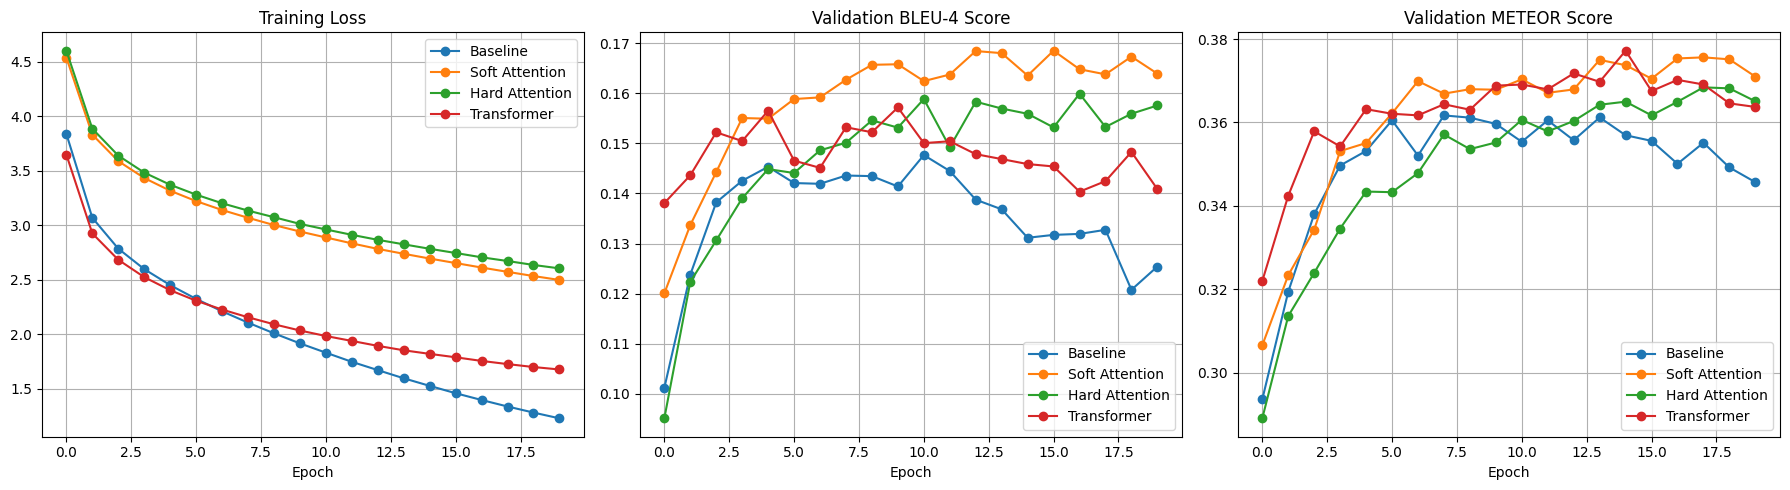


Model                | B-1      | B-2      | B-3      | B-4      | METEOR  
-------------------------------------------------------------------------------------
Baseline             |   63.16 |   40.30 |   24.53 |   14.77 |   35.54
Soft Attention       |   66.41 |   43.83 |   27.48 |   16.85 |   37.05
Hard Attention       |   65.59 |   42.53 |   26.28 |   15.99 |   36.50
Transformer          |   64.47 |   41.62 |   25.89 |   15.72 |   36.88

---> VISUALISATION SOFT ATTENTION


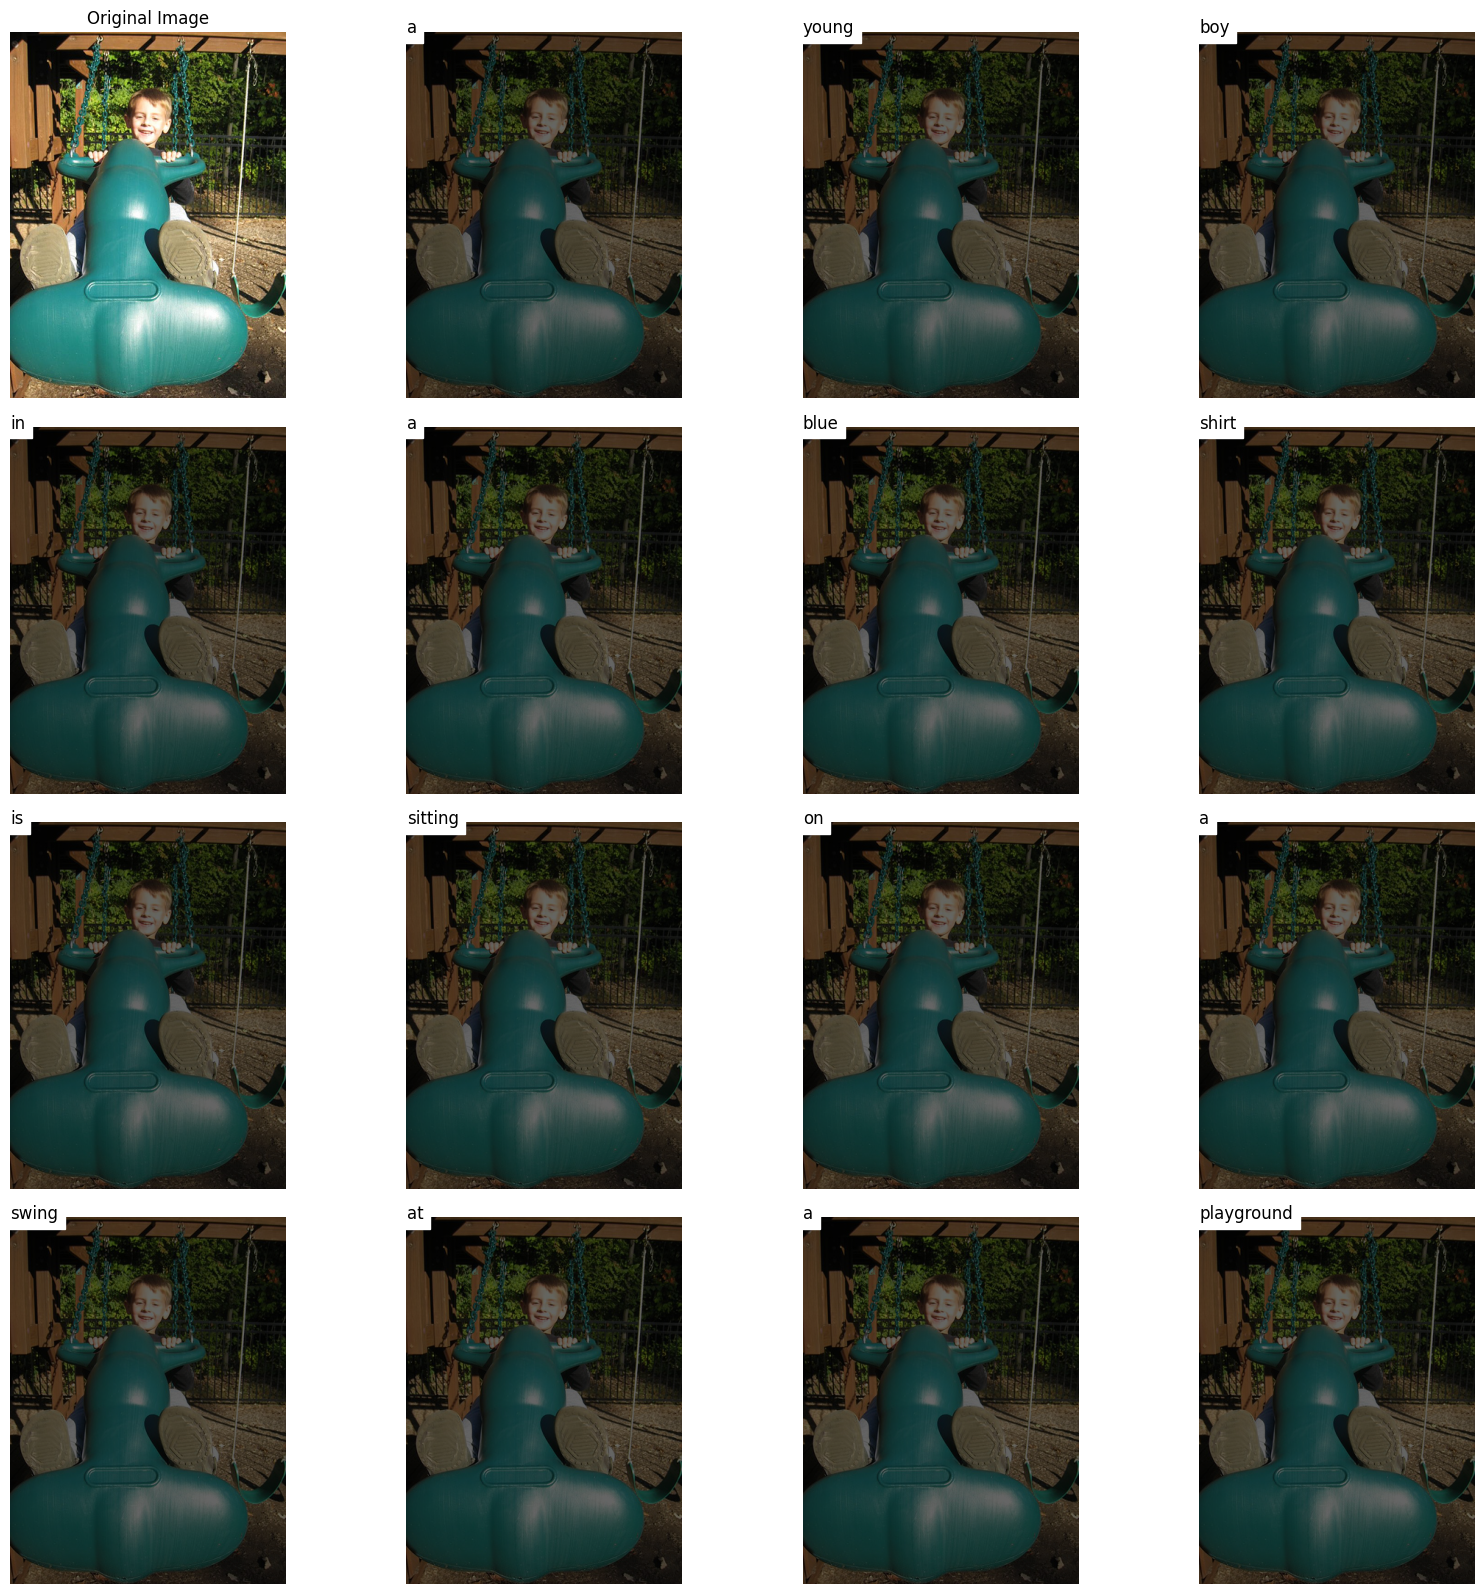

Caption générée: a young boy in a blue shirt is sitting on a swing at a playground

---> VISUALISATION HARD ATTENTION


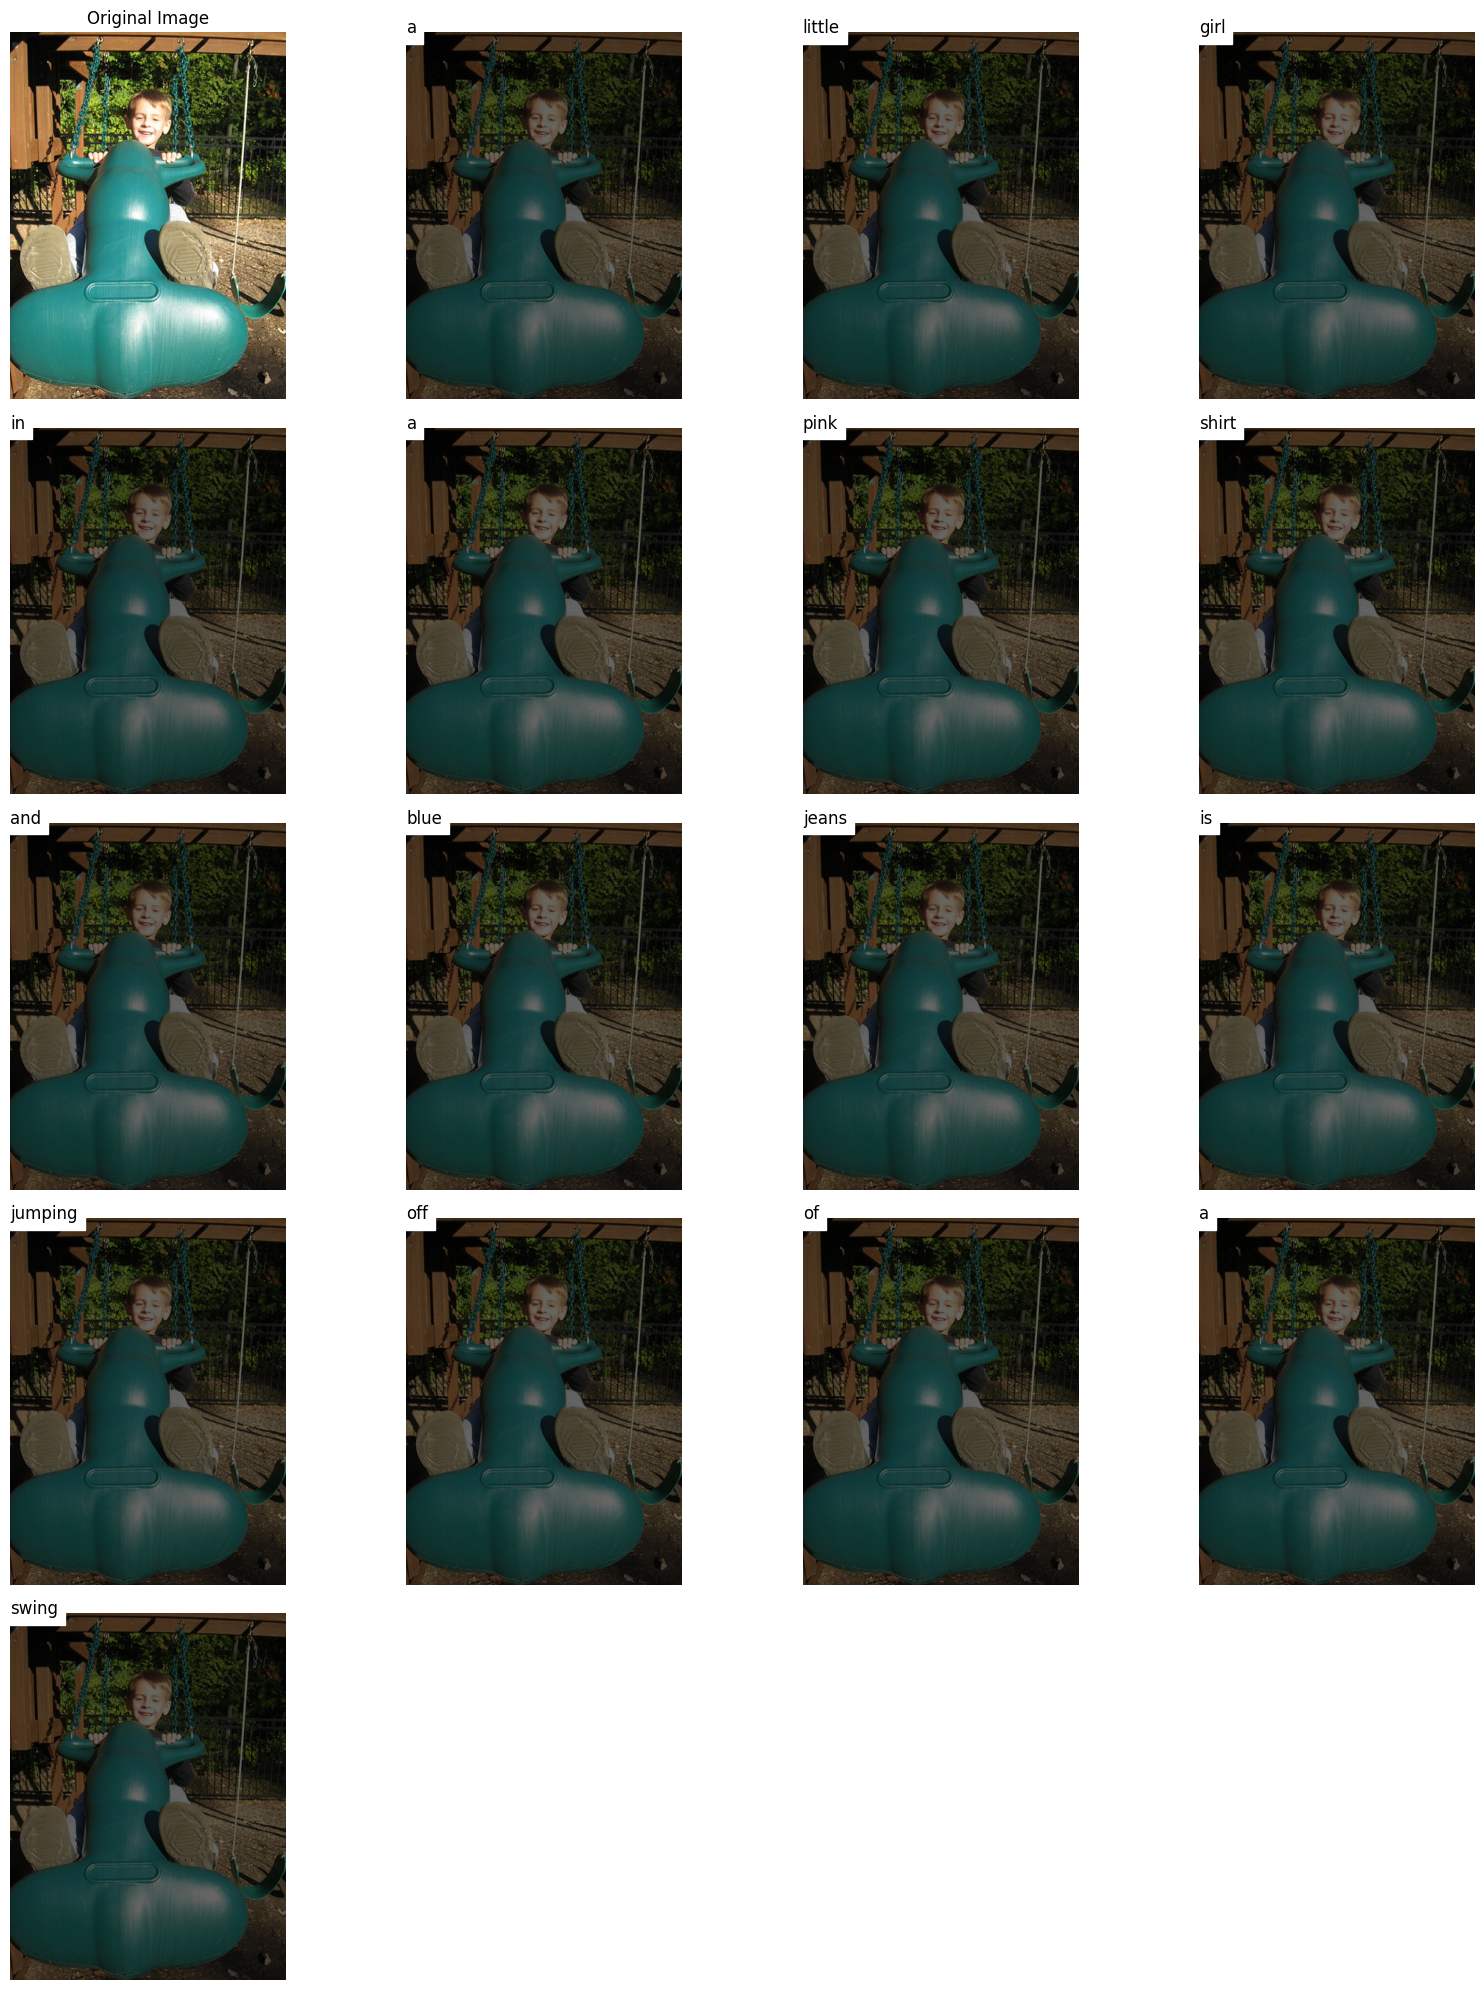

Caption générée: a little girl in a pink shirt and blue jeans is jumping off of a swing


In [70]:
if len(train_loader) > 0:
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    for model_name, hist in history.items(): plt.plot(hist['train'], label=model_name, marker='o')
    plt.title('Training Loss'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True)
    
    plt.subplot(1, 3, 2)
    for model_name, hist in history.items(): plt.plot([m['bleu4'] for m in hist['metrics']], label=model_name, marker='o')
    plt.title('Validation BLEU-4 Score'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True)
    
    plt.subplot(1, 3, 3)
    for model_name, hist in history.items(): plt.plot([m['meteor'] for m in hist['metrics']], label=model_name, marker='o')
    plt.title('Validation METEOR Score'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# --- Bonus : Visualisation des cartes d'attention ---
def visualize_attention(image_name, encoder, decoder, is_hard=False, max_len=50):
    encoder.eval(); decoder.eval()
    img_path = os.path.join(IMG_DIR, image_name)
    original_img = Image.open(img_path).convert("RGB")
    image = transform_val(original_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        encoder_out = encoder(image)
        h, c = decoder.init_hidden_state(encoder_out)
        word = torch.tensor([vocab.word2idx['<start>']]).to(device)
        alphas, words = [], []
        
        for i in range(max_len):
            embeddings = decoder.embedding(word)
            attention_weighted_encoding, alpha = decoder.attention(encoder_out, h)
            gate = decoder.sigmoid(decoder.f_beta(h))
            attention_weighted_encoding = gate * attention_weighted_encoding
            
            h, c = decoder.decode_step(torch.cat([embeddings, attention_weighted_encoding], dim=1), (h, c))
            preds = decoder.fc(h)
            
            pred_word_idx = preds.argmax(dim=1)
            pred_word = vocab.idx2word[pred_word_idx.item()]
            
            if pred_word == '<end>': break
            words.append(pred_word)
            alphas.append(alpha.view(7, 7).cpu().numpy())
            word = pred_word_idx
            
    cols = 4
    rows = (len(words) + cols - 1) // cols + 1
    fig = plt.figure(figsize=(cols * 4, rows * 4))
    
    ax = fig.add_subplot(rows, cols, 1)
    ax.imshow(original_img)
    ax.set_title("Original Image")
    ax.axis('off')
    
    for i in range(len(words)):
        ax = fig.add_subplot(rows, cols, i + 2)
        ax.text(0, 1, f'{words[i]}', color='black', backgroundcolor='white', fontsize=12)
        ax.imshow(original_img)
        
        alpha_img = Image.fromarray(alphas[i])
        alpha_img = alpha_img.resize((original_img.size[0], original_img.size[1]), Image.BILINEAR)
        ax.imshow(alpha_img, cmap='jet', alpha=0.6)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()
    print("Caption générée:", " ".join(words))

def print_final_summary(history):
    """Affiche un tableau récapitulatif comme dans l'article Show, Attend and Tell."""
    print("\n" + "="*85)
    print(f"{'Model':<20} | {'B-1':<8} | {'B-2':<8} | {'B-3':<8} | {'B-4':<8} | {'METEOR':<8}")
    print("-" * 85)
    for model_name, hist in history.items():
        if not hist['metrics']: continue
        # On prend les meilleures métriques sur toute la durée de l'entraînement
        best_m = max(hist['metrics'], key=lambda x: x['bleu4'])
        print(f"{model_name:<20} | {best_m['bleu1']*100:>7.2f} | {best_m['bleu2']*100:>7.2f} | {best_m['bleu3']*100:>7.2f} | {best_m['bleu4']*100:>7.2f} | {best_m['meteor']*100:>7.2f}")
    print("="*85)

if len(train_loader) > 0:
    print_final_summary(history)
    sample_image = random.choice(test_imgs)
    print("\n---> VISUALISATION SOFT ATTENTION")
    visualize_attention(sample_image, spatial_enc, soft_dec, is_hard=False)
    print("\n---> VISUALISATION HARD ATTENTION")
    visualize_attention(sample_image, spatial_enc, hard_dec, is_hard=True)
